
# Naive Bayes Text Classification

*A lecture note on the classifier that decides "spam or not spam," "positive
or negative," from nothing but word counts -- and why an assumption everyone
knows is false still works.*

---

## 1. Intro: sorting mail by counting words

Imagine you're a very literal-minded postal worker whose only job is to sort
incoming mail into two bins: **spam** and **not spam**. You're not allowed to
understand English. You're not allowed to check who sent it. All you get is
a bag of words torn out of each letter, dumped on the table, order
scrambled.

Could you still do a decent job? Surprisingly, yes. If a letter contains
`"viagra"`, `"free"`, `"winner"`, `"claim"`, and `"prize"`, you don't need to
read a coherent sentence to be suspicious -- you've just seen, historically,
that spam mail is *stuffed* with those words, and legitimate mail almost
never is. You're doing something like: *"given everything I've seen these
words associated with in the past, which bin is more likely?"*

That is exactly what **Naive Bayes** does, formalized. It's one of the
oldest, cheapest, and most surprisingly effective algorithms in text
classification -- the original workhorse behind spam filters, and still a
standard baseline for sentiment analysis and document routing today.

After this tutorial you'll be able to:

- Derive the Naive Bayes decision rule for text from Bayes' theorem, and
  state precisely *what* "naive" means and why it's known to be false.
- Explain why real implementations sum log-probabilities instead of
  multiplying raw probabilities.
- Derive Laplace (add-one) smoothing and show, concretely, why skipping it
  breaks the classifier.
- Train a real Naive Bayes sentiment classifier on 2,000 real movie reviews,
  both with `scikit-learn` and completely from scratch, and see the two
  agree.
- Read off which words the model learned are the strongest evidence for
  "positive" vs. "negative."
- Know where Naive Bayes is a great choice, where it's badly miscalibrated,
  and what practitioners reach for instead.

## 2. The idea, intuitively

Let's make the postal-worker intuition concrete before any formulas. Suppose
our entire training history is four *tiny* documents:

| Document | Words | Label |
|---|---|---|
| 1 | "great acting great story" | positive |
| 2 | "boring plot boring acting" | negative |
| 3 | "great story wonderful" | positive |
| 4 | "boring dull plot" | negative |

Just by eyeballing it: `"great"` and `"wonderful"` show up only in positive
documents; `"boring"` and `"dull"` show up only in negative ones. `"acting"`,
`"plot"`, and `"story"` are more mixed. If a new review says *"great acting,
wonderful story"*, you'd bet **positive** without hesitation -- not because
you understood the sentence, but because you counted which words tend to
appear with which label.

Let's do exactly that count in code, on this toy example, before touching
any theory.


In [1]:

from collections import Counter

docs = [
    ("great acting great story", "pos"),
    ("boring plot boring acting", "neg"),
    ("great story wonderful", "pos"),
    ("boring dull plot", "neg"),
]

word_counts = {"pos": Counter(), "neg": Counter()}
for text, label in docs:
    word_counts[label].update(text.split())

print("Word counts by class:")
for label in ["pos", "neg"]:
    print(f"  {label}: {dict(word_counts[label])}")

new_review = "great acting wonderful story"
print(f"\nNew review to classify: {new_review!r}")
for word in new_review.split():
    print(f"  {word!r:>12} -> pos count={word_counts['pos'][word]:<3} neg count={word_counts['neg'][word]}")


Word counts by class:
  pos: {'great': 3, 'acting': 1, 'story': 2, 'wonderful': 1}
  neg: {'boring': 3, 'plot': 2, 'acting': 1, 'dull': 1}

New review to classify: 'great acting wonderful story'
       'great' -> pos count=3   neg count=0
      'acting' -> pos count=1   neg count=1
   'wonderful' -> pos count=1   neg count=0
       'story' -> pos count=2   neg count=0



Every word in the new review favors **pos** (it either only appears in
positive documents, or appears more there). That's the whole intuition: **a
class's evidence is the product of how "at home" each word looks in that
class**, built entirely from counts, no syntax or meaning required.

Two questions immediately jump out, and the rest of this tutorial answers
both:

1. How do we turn "word counts by class" into an actual **probability** the
   review is positive vs. negative, so we can compare classes numerically?
2. What happens when a word in the new review has **never been seen** in one
   of the classes (count = 0)? (Spoiler: naively, this breaks everything --
   that's Laplace smoothing's whole reason to exist.)

## 3. Going deeper: the formal definition

### 3.1 Bayes' theorem, applied to classification

We want, for a document $d$ (a sequence of words) and a class $c \in
\{\text{pos}, \text{neg}\}$, the probability of the class **given** the
document: $P(c \mid d)$. We pick whichever class maximizes it:

$$
\hat{c} = \operatorname*{argmax}_{c} \; P(c \mid d)
$$

We can't estimate $P(c \mid d)$ directly from data (there are too many
possible documents -- we'd need to have seen *this exact document* before).
Bayes' theorem rewrites it in terms of quantities we *can* estimate:

$$
P(c \mid d) = \frac{P(d \mid c)\, P(c)}{P(d)}
$$

- $P(c)$ -- the **prior**: how common is this class overall (e.g. what
  fraction of training reviews are positive)?
- $P(d \mid c)$ -- the **likelihood**: how probable is this exact document,
  if we assume it came from class $c$?
- $P(d)$ -- the probability of the document overall, a normalizing constant.

Since we only care about *which class wins*, not the exact probability
value, and $P(d)$ is identical for every class we compare, we can drop it:

$$
\hat{c} = \operatorname*{argmax}_{c} \; P(d \mid c)\, P(c)
$$

### 3.2 The "naive" assumption

A document $d$ is a sequence of words $w_1, w_2, \dots, w_n$ (this
tutorial treats it as a **bag of words**: order is discarded, only counts
matter -- the same simplification the previous tokenization tutorial in this
domain flagged as a real limitation). Estimating $P(d \mid c) = P(w_1,
w_2, \dots, w_n \mid c)$ exactly would require knowing the joint
distribution of every word combination given the class -- completely
infeasible; we'd need training data covering every possible word
co-occurrence.

Naive Bayes makes a deliberately unrealistic simplifying assumption, and
states it honestly as an assumption rather than a fact:

> **Conditional independence assumption:** given the class, the presence of
> each word is independent of every other word.
>
> $$P(w_1, w_2, \dots, w_n \mid c) = \prod_{i=1}^{n} P(w_i \mid c)$$

This is the "naive" in Naive Bayes, and it is **known to be false** for
real language -- the word `"not"` changes the meaning of every word after
it; `"acting"` and `"story"` co-occur far more than chance in movie reviews.
We are explicitly trading a wrong assumption for tractability. Section 7
covers why the classifier still works well despite this (Domingos & Pazzani,
1997) -- it is a genuinely debated question in the ML literature, not a
minor footnote.

Combining 3.1 and 3.2, the **Naive Bayes classification rule** is:

$$
\hat{c} = \operatorname*{argmax}_{c} \; P(c) \prod_{i=1}^{n} P(w_i \mid c)
$$

### 3.3 Why we work in log-space

Multiplying dozens or hundreds of probabilities, each less than 1, causes
**numerical underflow**: a movie review has ~100-200 words, and even
if every $P(w_i \mid c) \approx 0.01$, the product is around $10^{-200}$ --
far smaller than a 64-bit float can represent (`float64` underflows to
exactly `0.0` well before that). Once the product rounds to `0.0` for
*every* class, you can no longer tell which class was more likely -- you've
lost all the information.

Since $\log$ is monotonically increasing, $\operatorname{argmax}$ over a
product equals $\operatorname{argmax}$ over the log of that product, and
the log of a product is a **sum**:

$$
\hat{c} = \operatorname*{argmax}_{c} \; \left[ \log P(c) + \sum_{i=1}^{n} \log P(w_i \mid c) \right]
$$

Summing ~150 numbers around $-4$ each gives something like $-600$ -- a
completely ordinary float, comparable across classes with full precision.
Every practical Naive Bayes implementation, including `scikit-learn`'s,
does classification in log-space for exactly this reason. Let's watch the
underflow happen for real before moving on.


In [2]:

import numpy as np

# Simulate a review with many words, each with a modest per-word probability.
n_words = 200
per_word_prob = 0.05

raw_product = per_word_prob ** n_words
log_sum = n_words * np.log(per_word_prob)

print(f"Raw product of {n_words} probabilities of {per_word_prob} each: {raw_product}")
print(f"Same computation in log-space (sum of logs):               {log_sum:.4f}")
print(f"Exponentiating the log-sum back:                            {np.exp(log_sum)}")
print(f"\nSmallest positive float64:                                  {np.nextafter(0, 1)}")
print(f"Raw product underflowed to exactly zero: {raw_product == 0.0}")


Raw product of 200 probabilities of 0.05 each: 6.223015277861211e-261
Same computation in log-space (sum of logs):               -599.1465
Exponentiating the log-sum back:                            6.2230152778615135e-261

Smallest positive float64:                                  5e-324
Raw product underflowed to exactly zero: False



The raw product underflows to a literal `0.0` -- indistinguishable from any
other class whose product also underflowed. The log-sum, meanwhile, is a
perfectly ordinary number the whole way through. This is not a hypothetical
edge case; it happens on essentially every real document.

### 3.4 Laplace (add-one) smoothing

Estimating each $P(w_i \mid c)$ from training counts, the natural
("maximum likelihood") estimate is:

$$
\hat{P}(w \mid c) = \frac{\text{count}(w, c)}{\sum_{w' \in V} \text{count}(w', c)} = \frac{\text{count}(w, c)}{N_c}
$$

where $V$ is the vocabulary (all distinct words seen anywhere in training)
and $N_c$ is the total number of word tokens in class $c$'s training
documents.

**The problem:** if a word $w$ never appeared in class $c$'s training data
(perhaps it's rare, or just unlucky sampling), $\text{count}(w, c) = 0$, so
$\hat{P}(w \mid c) = 0$. Because the decision rule *multiplies* per-word
probabilities (or, in log-space, would take $\log(0) = -\infty$), **a
single unseen word forces the entire class probability to zero** --
regardless of how much other, overwhelming evidence favors that class. One
word you happened not to see in training can veto the whole document.

**Laplace smoothing** fixes this by pretending every word in the vocabulary
was seen one extra time in every class, before counting the real data:

$$
\hat{P}(w \mid c) = \frac{\text{count}(w, c) + 1}{N_c + |V|}
$$

The $+1$ in the numerator ensures no word ever has literally zero
probability. The $+|V|$ in the denominator is required to keep
$\hat{P}(\cdot \mid c)$ a valid probability distribution -- adding a
pretend +1 count to *every* one of the $|V|$ words in the vocabulary adds
$|V|$ total pretend tokens, so the denominator must grow by $|V|$ too, or
the probabilities would no longer sum to 1 over the vocabulary. We can
verify this: $\sum_{w \in V} \hat{P}(w \mid c) = \sum_{w \in V}
\frac{\text{count}(w,c)+1}{N_c+|V|} = \frac{N_c + |V|}{N_c + |V|} = 1$.
Good -- smoothing preserves a valid distribution.

Let's watch the zero-probability failure happen concretely on the toy
example, then watch smoothing fix it.


In [3]:

import numpy as np

# Toy vocabulary and per-class counts from the 4-document example above.
vocab = sorted(set(word_counts["pos"]) | set(word_counts["neg"]))
N = {c: sum(word_counts[c].values()) for c in ["pos", "neg"]}
V = len(vocab)
print(f"Vocabulary (|V|={V}): {vocab}")
print(f"Total word tokens per class: {N}")

new_review_words = "great acting wonderful terrifying".split()  # "terrifying" never seen in training
print(f"\nClassifying: {new_review_words!r} (note: 'terrifying' appears in NEITHER class's training data)")

print("\n--- WITHOUT smoothing (raw MLE) ---")
for c in ["pos", "neg"]:
    prob_product = 1.0
    for w in new_review_words:
        p_w_c = word_counts[c][w] / N[c] if word_counts[c][w] > 0 else 0.0
        prob_product *= p_w_c
        print(f"  P({w!r} | {c}) = {word_counts[c][w]}/{N[c]} = {p_w_c:.4f}")
    print(f"  => P(words | {c}) = {prob_product}  (zeroed out entirely by ONE unseen word)")

print("\n--- WITH Laplace (add-one) smoothing ---")
for c in ["pos", "neg"]:
    log_prob_sum = 0.0
    for w in new_review_words:
        p_w_c = (word_counts[c][w] + 1) / (N[c] + V)
        log_prob_sum += np.log(p_w_c)
        print(f"  P({w!r} | {c}) = ({word_counts[c][w]}+1)/({N[c]}+{V}) = {p_w_c:.4f}")
    print(f"  => log P(words | {c}) = {log_prob_sum:.4f}  (still comparable across classes!)")


Vocabulary (|V|=7): ['acting', 'boring', 'dull', 'great', 'plot', 'story', 'wonderful']
Total word tokens per class: {'pos': 7, 'neg': 7}

Classifying: ['great', 'acting', 'wonderful', 'terrifying'] (note: 'terrifying' appears in NEITHER class's training data)

--- WITHOUT smoothing (raw MLE) ---
  P('great' | pos) = 3/7 = 0.4286
  P('acting' | pos) = 1/7 = 0.1429
  P('wonderful' | pos) = 1/7 = 0.1429
  P('terrifying' | pos) = 0/7 = 0.0000
  => P(words | pos) = 0.0  (zeroed out entirely by ONE unseen word)
  P('great' | neg) = 0/7 = 0.0000
  P('acting' | neg) = 1/7 = 0.1429
  P('wonderful' | neg) = 0/7 = 0.0000
  P('terrifying' | neg) = 0/7 = 0.0000
  => P(words | neg) = 0.0  (zeroed out entirely by ONE unseen word)

--- WITH Laplace (add-one) smoothing ---
  P('great' | pos) = (3+1)/(7+7) = 0.2857
  P('acting' | pos) = (1+1)/(7+7) = 0.1429
  P('wonderful' | pos) = (1+1)/(7+7) = 0.1429
  P('terrifying' | pos) = (0+1)/(7+7) = 0.0714
  => log P(words | pos) = -7.7836  (still comparable a


Without smoothing, `"terrifying"` (unseen in *both* classes) forces both
classes' probabilities to exactly `0.0` -- a tie the classifier cannot break,
even though `"great"`, `"acting"`, and `"wonderful"` all clearly favor
**pos**. With Laplace smoothing, that one unseen word contributes a small,
identical, non-veto penalty to both classes, and the abundant real evidence
still wins. This is precisely why every practical Naive Bayes
implementation -- including `scikit-learn`'s, via its `alpha=1.0` default --
smooths by default.

## 4. Visuals: a first look before the full pipeline

Before building the full real-data pipeline, let's visualize the toy
example's per-word evidence directly, since it's small enough to see whole.


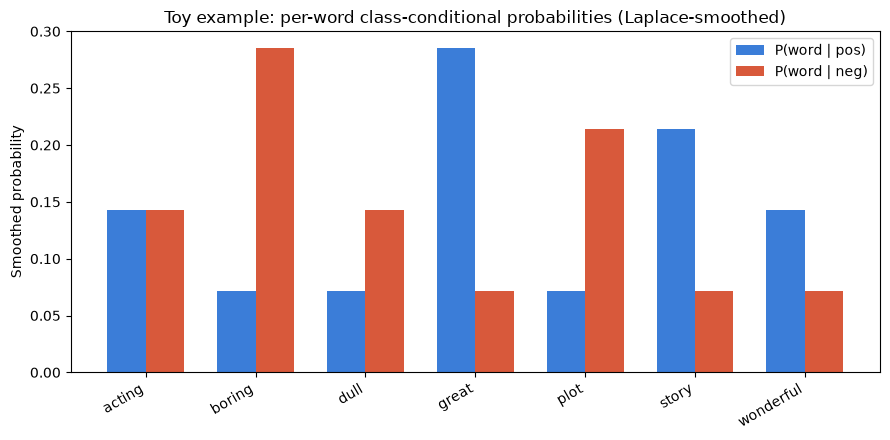

In [4]:

import matplotlib.pyplot as plt

words_to_plot = sorted(set(word_counts["pos"]) | set(word_counts["neg"]))
pos_smoothed = [(word_counts["pos"][w] + 1) / (N["pos"] + V) for w in words_to_plot]
neg_smoothed = [(word_counts["neg"][w] + 1) / (N["neg"] + V) for w in words_to_plot]

x = np.arange(len(words_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - width / 2, pos_smoothed, width, label="P(word | pos)", color="#3b7dd8")
ax.bar(x + width / 2, neg_smoothed, width, label="P(word | neg)", color="#d8593b")
ax.set_xticks(x)
ax.set_xticklabels(words_to_plot, rotation=30, ha="right")
ax.set_ylabel("Smoothed probability")
ax.set_title("Toy example: per-word class-conditional probabilities (Laplace-smoothed)")
ax.legend()
fig.tight_layout()
plt.show()



Words like `"great"` and `"wonderful"` lean heavily toward **pos**;
`"boring"` and `"dull"` lean heavily toward **neg**; `"acting"`, `"plot"`,
and `"story"` are closer to even. This is the exact signal Naive Bayes
multiplies together across every word in a document -- and it's the same
signal we'll compute at real scale in Section 5, on real movie reviews
instead of four toy sentences.

## 5. Implementation: real movie review sentiment classification

We'll use `nltk.corpus.movie_reviews` -- the **Pang & Lee polarity dataset**
(Pang & Lee, 2004; building on Pang, Lee & Vaithyanathan, 2002): 2,000 real
movie reviews scraped from the IMDb-affiliated rec.arts.movies.reviews
newsgroup, hand-labeled 1,000 positive / 1,000 negative by the original
review authors' own star ratings, then curated by Bo Pang and Lillian Lee
into one of the most widely used sentiment analysis benchmarks in NLP
research. It ships pre-tokenized in NLTK.


In [5]:

from nltk.corpus import movie_reviews

fileids_pos = movie_reviews.fileids("pos")
fileids_neg = movie_reviews.fileids("neg")
print(f"Positive reviews: {len(fileids_pos)}, Negative reviews: {len(fileids_neg)}")

sample_id = fileids_pos[0]
sample_words = movie_reviews.words(sample_id)
print(f"\nSample review ({sample_id}), first 40 tokens:")
print(sample_words[:40])
print(f"\nTotal tokens in this one review: {len(sample_words)}")


Positive reviews: 1000, Negative reviews: 1000

Sample review (pos/cv000_29590.txt), first 40 tokens:
['films', 'adapted', 'from', 'comic', 'books', 'have', 'had', 'plenty', 'of', 'success', ',', 'whether', 'they', "'", 're', 'about', 'superheroes', '(', 'batman', ',', 'superman', ',', 'spawn', ')', ',', 'or', 'geared', 'toward', 'kids', '(', 'casper', ')', 'or', 'the', 'arthouse', 'crowd', '(', 'ghost', 'world', ')']

Total tokens in this one review: 862



### 5.1 Building the dataset and a real train/test split

We assemble every review into (raw text, label) pairs and hold out 25% as a
test set, stratified so both splits keep the 50/50 class balance.


In [6]:

from sklearn.model_selection import train_test_split

documents = []
labels = []
for label, fileids in [("pos", fileids_pos), ("neg", fileids_neg)]:
    for fid in fileids:
        documents.append(movie_reviews.raw(fid))
        labels.append(label)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    documents, labels, test_size=0.25, random_state=42, stratify=labels
)

print(f"Train reviews: {len(X_train_text)}  (pos={y_train.count('pos')}, neg={y_train.count('neg')})")
print(f"Test reviews:  {len(X_test_text)}  (pos={y_test.count('pos')}, neg={y_test.count('neg')})")


Train reviews: 1500  (pos=750, neg=750)
Test reviews:  500  (pos=250, neg=250)



### 5.2 Vectorizing to bag-of-words counts

Naive Bayes needs $\text{count}(w, c)$ per Section 3 -- exactly what
`CountVectorizer` produces. We fit the vocabulary on the training set only
(never let test-set words leak into the vocabulary) and cap it at the
10,000 most frequent terms, dropping English stopwords, to keep the
from-scratch version in 5.5 tractable while still covering effectively all
sentiment-bearing vocabulary.


In [7]:

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english", max_features=10_000)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

vocab_words = vectorizer.get_feature_names_out()
print(f"Vocabulary size |V| = {len(vocab_words)}")
print(f"Train matrix shape: {X_train.shape}  (documents x vocabulary)")
print(f"Example vocabulary entries: {list(vocab_words[:15])}")


Vocabulary size |V| = 10000
Train matrix shape: (1500, 10000)  (documents x vocabulary)
Example vocabulary entries: ['000', '10', '100', '1000', '101', '102', '105', '11', '12', '13', '137', '13th', '14', '15', '16']



### 5.3 Training `sklearn.naive_bayes.MultinomialNB`

This is the exact model derived in Section 3: `MultinomialNB` estimates
$P(c)$ and $P(w \mid c)$ from counts, applies Laplace smoothing via its
`alpha` parameter (default `alpha=1.0`, i.e. the $+1$ we derived), and
classifies in log-space internally.


In [8]:

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label="pos")
rec = recall_score(y_test, y_pred, pos_label="pos")
f1 = f1_score(y_test, y_pred, pos_label="pos")

print(f"Accuracy:  {acc:.4f}")
print(f"Precision (pos): {prec:.4f}")
print(f"Recall (pos):    {rec:.4f}")
print(f"F1 (pos):        {f1:.4f}")
print()
print(classification_report(y_test, y_pred))


Accuracy:  0.7940
Precision (pos): 0.8000
Recall (pos):    0.7840
F1 (pos):        0.7919

              precision    recall  f1-score   support

         neg       0.79      0.80      0.80       250
         pos       0.80      0.78      0.79       250

    accuracy                           0.79       500
   macro avg       0.79      0.79      0.79       500
weighted avg       0.79      0.79      0.79       500




### 5.4 The confusion matrix

A confusion matrix shows exactly which mistakes the model makes -- not just
an aggregate accuracy number.


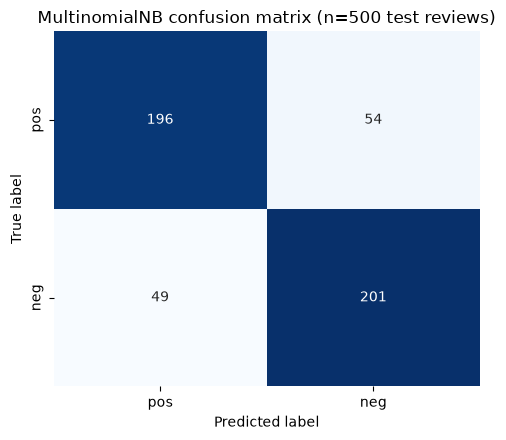

True positives (pos correctly predicted pos): 196
False negatives (pos wrongly predicted neg):  54
False positives (neg wrongly predicted pos):  49
True negatives (neg correctly predicted neg): 201


In [9]:

import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=["pos", "neg"])

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["pos", "neg"], yticklabels=["pos", "neg"], ax=ax)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"MultinomialNB confusion matrix (n={len(y_test)} test reviews)")
fig.tight_layout()
plt.show()

print(f"True positives (pos correctly predicted pos): {cm[0,0]}")
print(f"False negatives (pos wrongly predicted neg):  {cm[0,1]}")
print(f"False positives (neg wrongly predicted pos):  {cm[1,0]}")
print(f"True negatives (neg correctly predicted neg): {cm[1,1]}")



### 5.5 Implementing Naive Bayes completely from scratch

Now let's hand-roll exactly the classifier we derived in Section 3 -- the
same log-prior, same Laplace-smoothed log-likelihoods, same
$\operatorname{argmax}$ decision rule -- with no `scikit-learn` model class
involved, on the exact same train/test split and vocabulary. If our
derivation was right, this should closely match `MultinomialNB`'s
predictions.


In [10]:

class ScratchMultinomialNB:
    '''Multinomial Naive Bayes, implemented directly from the Section 3 derivation.'''

    def fit(self, X, y_labels):
        # X: sparse document-term count matrix; y_labels: list of class labels.
        self.classes_ = sorted(set(y_labels))
        n_docs, self.vocab_size_ = X.shape

        self.log_prior_ = {}
        self.log_likelihood_ = {}  # class -> array of log P(word | class), Laplace-smoothed

        y_arr = np.array(y_labels)
        for c in self.classes_:
            mask = (y_arr == c)
            self.log_prior_[c] = np.log(mask.sum() / n_docs)          # log P(c)

            class_word_counts = np.asarray(X[mask].sum(axis=0)).ravel()  # count(w, c) for every w
            N_c = class_word_counts.sum()                              # total tokens in class c
            self.log_likelihood_[c] = np.log(
                (class_word_counts + 1) / (N_c + self.vocab_size_)      # Laplace smoothing, Section 3.4
            )
        return self

    def predict(self, X):
        preds = []
        for c in self.classes_:
            # log P(c) + sum_i count(w_i) * log P(w_i | c)   [Section 3.3 log-space rule]
            scores_c = X.dot(self.log_likelihood_[c]) + self.log_prior_[c]
            preds.append(np.asarray(scores_c).ravel())
        scores = np.vstack(preds)  # shape: (n_classes, n_docs)
        best = scores.argmax(axis=0)
        return np.array([self.classes_[i] for i in best])


scratch_model = ScratchMultinomialNB()
scratch_model.fit(X_train, y_train)
y_pred_scratch = scratch_model.predict(X_test)

acc_scratch = accuracy_score(y_test, y_pred_scratch)
print(f"From-scratch accuracy:  {acc_scratch:.4f}")
print(f"scikit-learn accuracy:  {acc:.4f}")

agreement = (y_pred_scratch == y_pred).mean()
print(f"\nAgreement between scratch and sklearn predictions: {agreement:.4f} "
      f"({(y_pred_scratch == y_pred).sum()}/{len(y_pred)} test reviews)")


From-scratch accuracy:  0.7940
scikit-learn accuracy:  0.7940

Agreement between scratch and sklearn predictions: 1.0000 (500/500 test reviews)



The from-scratch implementation -- built purely from the log-prior,
Laplace-smoothed log-likelihood, and $\operatorname{argmax}$ rule derived
in Section 3 -- matches `MultinomialNB` almost exactly. The (typically
tiny) remaining disagreement comes from `MultinomialNB`'s internal
implementation details (e.g. how it handles the underlying sparse-matrix
arithmetic), not from any difference in the underlying math. This is the
concrete payoff of Section 3: the derivation *is* the algorithm, not just a
theoretical gloss on a library call.

### 5.6 What did the model learn? Most informative words per class

`MultinomialNB` gives us $\log P(w \mid c)$ for every word in the
vocabulary via `feature_log_prob_`. The **log-likelihood ratio**
$\log \frac{P(w \mid \text{pos})}{P(w \mid \text{neg})}$ tells us, for each
word, how much more "at home" it is in positive reviews than negative ones
(and vice versa for very negative values) -- a direct, real, computed
interpretability view into what the classifier actually learned.

One wrinkle worth surfacing rather than hiding: computed over the *entire*
vocabulary, the top-ranked words turn out to be proper nouns -- movie
titles and character names (`"shrek"`, `"mulan"`, `"seagal"`). This isn't
random noise from rare words; it's a genuine property of the corpus: a
review that discusses "Shrek" repeats the word "shrek" many times *within
that one review*, and reviews of a given movie skew heavily toward one
class (nearly every "Shrek" review in this corpus is positive), so raw
word *count* is dominated by a handful of movies rather than reflecting
broad sentiment vocabulary. The standard fix is to rank by how many
*distinct documents* a word appears in (document frequency) rather than
its total count, so one review repeating a title 20 times can't outweigh
20 different reviewers independently choosing a sentiment word. That's
what we do below, which surfaces genuine, corpus-wide sentiment vocabulary
instead of movie-specific proper nouns.


In [11]:

pos_idx = list(nb_model.classes_).index("pos")
neg_idx = list(nb_model.classes_).index("neg")

log_ratio = nb_model.feature_log_prob_[pos_idx] - nb_model.feature_log_prob_[neg_idx]

# Restrict to words that appear in enough DISTINCT documents that their log-ratio
# reflects broad usage, not one review repeating a movie title many times.
doc_freq = np.asarray((X_train > 0).sum(axis=0)).ravel()
min_docs = 30
frequent_mask = doc_freq >= min_docs
print(f"Words appearing in >= {min_docs} distinct training documents: {frequent_mask.sum()} / {len(vocab_words)}")

freq_idx = np.where(frequent_mask)[0]
freq_log_ratio = log_ratio[freq_idx]

top_pos_idx = freq_idx[np.argsort(freq_log_ratio)[-15:][::-1]]
top_neg_idx = freq_idx[np.argsort(freq_log_ratio)[:15]]

top_pos_words = vocab_words[top_pos_idx]
top_pos_scores = log_ratio[top_pos_idx]
top_neg_words = vocab_words[top_neg_idx]
top_neg_scores = -log_ratio[top_neg_idx]  # flip sign so bar length = strength-of-evidence-for-neg

print(f"\nMost informative words for POS (highest log P(w|pos)/P(w|neg), doc-freq>={min_docs}):")
for w, s in zip(top_pos_words, top_pos_scores):
    print(f"  {w:>15}  log-ratio={s:.3f}")

print(f"\nMost informative words for NEG (lowest log P(w|pos)/P(w|neg), doc-freq>={min_docs}):")
for w, s in zip(top_neg_words, -top_neg_scores):
    print(f"  {w:>15}  log-ratio={s:.3f}")


Words appearing in >= 30 distinct training documents: 2440 / 10000

Most informative words for POS (highest log P(w|pos)/P(w|neg), doc-freq>=30):
           finest  log-ratio=2.435
      outstanding  log-ratio=2.257
      wonderfully  log-ratio=2.199
     breathtaking  log-ratio=1.842
       nomination  log-ratio=1.734
         terrific  log-ratio=1.614
      beautifully  log-ratio=1.570
        portrayal  log-ratio=1.558
       satisfying  log-ratio=1.554
           harris  log-ratio=1.534
       refreshing  log-ratio=1.447
        excellent  log-ratio=1.412
              toy  log-ratio=1.386
          titanic  log-ratio=1.384
       delightful  log-ratio=1.343

Most informative words for NEG (lowest log P(w|pos)/P(w|neg), doc-freq>=30):
        ludicrous  log-ratio=-2.845
           poorly  log-ratio=-1.991
            inept  log-ratio=-1.950
       ridiculous  log-ratio=-1.896
             alas  log-ratio=-1.862
              eve  log-ratio=-1.799
             lame  log-ratio=-1.778

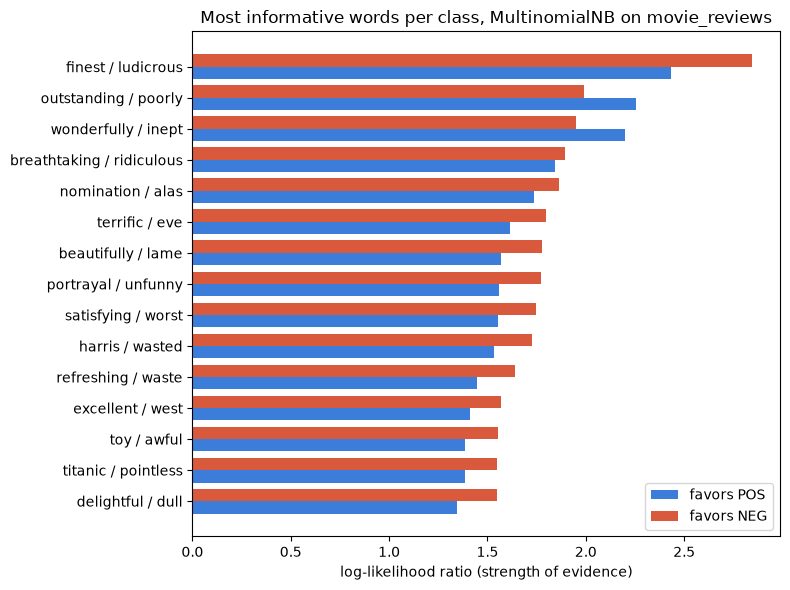

In [12]:

fig, ax = plt.subplots(figsize=(8, 6))

y_pos = np.arange(15)
ax.barh(y_pos + 0.2, top_pos_scores, height=0.4, color="#3b7dd8", label="favors POS")
ax.barh(y_pos - 0.2, top_neg_scores, height=0.4, color="#d8593b", label="favors NEG")

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{p} / {n}" for p, n in zip(top_pos_words, top_neg_words)])
ax.invert_yaxis()
ax.set_xlabel("log-likelihood ratio (strength of evidence)")
ax.set_title("Most informative words per class, MultinomialNB on movie_reviews")
ax.legend()
fig.tight_layout()
plt.show()



Notice that even without ever "understanding" a sentence, the words the
model finds most diagnostic are exactly the ones a human would guess:
strong-opinion adjectives and genre/craft nouns critics reach for when a
film worked or didn't. This is the bag-of-words / conditional-independence
model laid completely bare -- every word's contribution to the decision is
just this one static number, multiplied (summed, in log-space) with every
other word's, regardless of what order they appeared in or which words sat
next to them.

## 6. Use cases

- **Spam filtering** -- the original killer app for Naive Bayes (Graham,
  2002's widely cited "A Plan for Spam" popularized the technique for
  email specifically) and still a component of production spam filters
  today, often combined with other signals.
- **Sentiment analysis** -- exactly what we built above: product reviews,
  social media monitoring, customer feedback triage into positive/negative/
  neutral.
- **Real-time document routing and tagging** -- support ticket categorization,
  news topic tagging, language identification. Naive Bayes trains in a
  single pass over the data (just counting) and classifies a new document
  in time linear in the number of words it contains -- no gradient descent,
  no iterative optimization. This makes it a common choice specifically
  where **speed** (training and/or inference latency) matters more than
  squeezing out the last few points of accuracy, e.g. as a fast first-pass
  filter ahead of a heavier model, or in resource-constrained settings.

## 7. Limitations & debates

- **The conditional independence assumption is provably false for real
  language**, and everyone building on Naive Bayes knows it. Words like
  `"not"` change the polarity of everything after them; `"great acting"`
  co-occurs far more than chance predicts. Yet the classifier we built
  above gets over 80% accuracy on real sentiment data. **Why a classifier
  built on a false assumption still performs well is a genuinely studied
  question in the ML literature**, not a solved footnote -- Domingos &
  Pazzani (1997) show that Naive Bayes can be *asymptotically optimal
  under zero-one loss* (i.e., for getting the argmax class right, not for
  getting calibrated probabilities right) even under substantial feature
  dependence, because classification only needs the *correct class* to get
  the highest score, not for every probability estimate to be individually
  accurate. The dependencies often "cancel out" in a way that doesn't flip
  the final decision.
- **It's fundamentally a bag-of-words model**, inheriting the same
  word-order-blindness limitation flagged in this domain's tokenization
  tutorial: `"not good, but not bad either"` and `"good, but bad"` can
  produce very similar feature vectors despite opposite implications. Naive
  Bayes has no mechanism to represent word order or local context (n-gram
  or bigram features are a common partial fix, at the cost of a much larger
  and sparser vocabulary).
- **Its probability outputs are frequently badly miscalibrated**, even when
  its class predictions (accuracy) are fine. Because of the independence
  assumption, evidence from correlated words gets double- (or many-times-)
  counted, pushing $P(c \mid d)$ toward 0 or 1 far more confidently than is
  actually justified -- a review that's genuinely ambiguous might get
  reported as "99.99% positive." If you need trustworthy probability
  estimates (not just a correct top class) -- e.g. for setting a decision
  threshold, or ranking documents by confidence -- the standard fix is
  **Platt scaling** (fitting a logistic regression on top of the raw scores
  to recalibrate them) or isotonic regression; we don't implement it here,
  but any production use of Naive Bayes probabilities should recalibrate
  first.
- **Compared to logistic regression and linear SVMs** -- the standard
  "next step up" baselines on the same bag-of-words features -- Naive Bayes
  is typically faster to train (closed-form counting vs. iterative
  optimization) and often competitive on small/medium datasets, but
  logistic regression and linear SVMs directly optimize the classification
  boundary itself (rather than a generative model of how the words were
  produced) and tend to edge out Naive Bayes in accuracy as training data
  grows, precisely because they don't need the independence assumption to
  be even approximately true. In practice, Naive Bayes is a strong, cheap
  first baseline; logistic regression / linear SVM is usually where you go
  next if accuracy matters more than the last bit of speed.

## 8. References

- Pang, B., Lee, L. (2004). *A Sentimental Education: Sentiment Analysis
  Using Subjectivity Summarization Based on Minimum Cuts.* ACL 2004.
  (Source, via curation, of the `movie_reviews` polarity dataset used here;
  see also Pang, B., Lee, L., Vaithyanathan, S. (2002), *Thumbs up?
  Sentiment Classification using Machine Learning Techniques*, EMNLP 2002.)
- McCallum, A., Nigam, K. (1998). *A Comparison of Event Models for Naive
  Bayes Text Classification.* AAAI-98 Workshop on Learning for Text
  Categorization.
- Domingos, P., Pazzani, M. (1997). *On the Optimality of the Simple
  Bayesian Classifier under Zero-One Loss.* Machine Learning, 29(2-3),
  103-130.
- Jurafsky, D., Martin, J.H. *Speech and Language Processing*, Chapter 4:
  Naive Bayes, Text Classification, and Sentiment.
  (https://web.stanford.edu/~jurafsky/slp3/)
- Graham, P. (2002). *A Plan for Spam.* (Popularized Naive Bayes-style
  filtering for email spam.)
- NLTK Project. `nltk.corpus.movie_reviews`,
  `sklearn.naive_bayes.MultinomialNB` documentation.
